<a href="https://colab.research.google.com/github/Tassigulias/projeto_avaliativo_modulo-1_SCTEC/blob/main/projeto_avaliativo_T3_tassiana_gulias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importação da biblioteca pandas e conexão com o arquivo via link do GitHub.

Em FreeSQL, foi realizado LEFT JOIN EMPLOYEES com JOBS e DEPARTAMENTS. E aplicado o filtro WHERE department_name is not NULL.

In [54]:
import pandas as pd

url = 'https://raw.githubusercontent.com/Tassigulias/projeto_avaliativo_modulo-1_SCTEC/refs/heads/main/query_1.csv'

df1 = pd.read_csv(url)

#visualização das 5 primeiras linhas:
df1.head()


,SALARY,EMPLOYEE_ID,HIRE_DATE,DEPARTMENT_NAME,JOB_TITLE
0,24000,100,2013-06-17T00:00:00Z,Executive,President
1,17000,101,2015-09-21T00:00:00Z,Executive,Administration Vice President
2,17000,102,2011-01-13T00:00:00Z,Executive,Administration Vice President
3,4400,200,2013-09-17T00:00:00Z,Administration,Administration Assistant
4,12008,108,2012-08-17T00:00:00Z,Finance,Finance Manager


In [55]:
#análise do número de colunas e linhas
df1.shape

(106, 5)

In [56]:
#obtendo os nomes das colunas
df1.columns

Index(['SALARY', 'EMPLOYEE_ID', 'HIRE_DATE', 'DEPARTMENT_NAME', 'JOB_TITLE'], dtype='object')

In [57]:
#renomeando as colunas
df1 = df1.rename(columns={
    'SALARY': 'salario',
    'EMPLOYEE_ID': 'codigo_do_funcionario',
    'HIRE_DATE': 'data_da_contratacao',
    'DEPARTMENT_NAME': 'nome_do_departamento',
    'JOB_TITLE': 'cargo'})

df1.columns

Index(['salario', 'codigo_do_funcionario', 'data_da_contratacao',
       'nome_do_departamento', 'cargo'],
      dtype='object')

In [58]:
#obtendo as medidas estatísticas básicas
df1['salario'].describe()

,salario
count,106.000000
mean,6456.754717
std,3927.798234
min,2100.000000
25%,3100.000000
50%,6150.000000
75%,8950.000000
max,24000.000000


In [59]:
#calculando a moda
moda_salario = df1['salario'].mode()
print(moda_salario)

0    2500
Name: salario, dtype: int64


In [60]:
#analisando as informações da tabela
print(df1.info())

#analisando os tipos de dados
print(df1.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   salario                106 non-null    int64 
 1   codigo_do_funcionario  106 non-null    int64 
 2   data_da_contratacao    106 non-null    object
 3   nome_do_departamento   106 non-null    object
 4   cargo                  106 non-null    object
dtypes: int64(2), object(3)
memory usage: 4.3+ KB
None
salario                   int64
codigo_do_funcionario     int64
data_da_contratacao      object
nome_do_departamento     object
cargo                    object
dtype: object


In [61]:
#verificando valores nulos
df1.isnull().sum()

,0
salario,0
codigo_do_funcionario,0
data_da_contratacao,0
nome_do_departamento,0
cargo,0


Na função acima, observa-se que não foram encontrados valores nulos, pois já foram tratados anteriormente no FreeSQL (WHERE ... IS NOT NULL).

In [62]:
#convertendo a coluna para datetime no padrão AAAA-MM-DD
df1['data_da_contratacao'] = pd.to_datetime(df1['data_da_contratacao']).dt.tz_localize(None)

df1['data_da_contratacao'].head()

,data_da_contratacao
0,2013-06-17
1,2015-09-21
2,2011-01-13
3,2013-09-17
4,2012-08-17


In [63]:
#analisando o intervalo das contratações
print(df1['data_da_contratacao'].min())
print(df1['data_da_contratacao'].max())

2011-01-13 00:00:00
2018-04-21 00:00:00


In [64]:
#descobrindo número de linhas duplicadas
df1.duplicated().sum()

np.int64(0)

In [65]:
# média salarial por departamento
df1.groupby('nome_do_departamento')['salario'].mean()

,salario
nome_do_departamento,
Accounting,10154.000000
Administration,4400.000000
Executive,19333.333333
Finance,8601.333333
Human Resources,6500.000000
IT,5760.000000
Marketing,9500.000000
Public Relations,10000.000000
Purchasing,4150.000000


In [66]:
# colocando reset_index, renomeando as colunas e colocando em ordem decrescente
dept_salario = (df1.groupby('nome_do_departamento').agg(media_salarial=('salario', 'mean')).sort_values(by='media_salarial',ascending=False).reset_index())

dept_salario

,nome_do_departamento,media_salarial
0,Executive,19333.333333
1,Accounting,10154.000000
2,Public Relations,10000.000000
3,Marketing,9500.000000
4,Sales,8955.882353
5,Finance,8601.333333
6,Human Resources,6500.000000
7,IT,5760.000000
8,Administration,4400.000000
9,Purchasing,4150.000000


In [67]:
# média salarial por cargo
df1.groupby('cargo')['salario'].mean().sort_values(ascending=False)

,salario
cargo,
President,24000.000000
Administration Vice President,17000.000000
Marketing Manager,13000.000000
Sales Manager,12200.000000
Finance Manager,12008.000000
Accounting Manager,12008.000000
Purchasing Manager,11000.000000
Public Relations Representative,10000.000000
Sales Representative,8396.551724


In [68]:
# colocando reset_index, renomeando as colunas e colocando em ordem decrescente
cargo_salario = (df1.groupby('cargo').agg(media_salarial=('salario', 'mean')).sort_values(by='media_salarial',ascending=False).reset_index())

cargo_salario

,cargo,media_salarial
0,President,24000.000000
1,Administration Vice President,17000.000000
2,Marketing Manager,13000.000000
3,Sales Manager,12200.000000
4,Finance Manager,12008.000000
5,Accounting Manager,12008.000000
6,Purchasing Manager,11000.000000
7,Public Relations Representative,10000.000000
8,Sales Representative,8396.551724
9,Public Accountant,8300.000000


In [69]:
#descobrindo a quantidade de funcionários em cada cargo
df1['cargo'].value_counts().reset_index()

,cargo,count
0,Sales Representative,29
1,Stock Clerk,20
2,Shipping Clerk,20
3,Programmer,5
4,Stock Manager,5
5,Sales Manager,5
6,Accountant,5
7,Purchasing Clerk,5
8,Administration Vice President,2
9,Administration Assistant,1


In [89]:
# para saber os salários de um mesmo cargo pela data de contratação

# filtrando os Sales Representative
sales_rep = df1[df1['cargo'] == 'Sales Representative']

#selecionando as colunas e ordenando do mais antigo para o mais recente
resultado = sales_rep[['data_da_contratacao', 'salario']].sort_values(by='data_da_contratacao')

print(resultado)

   data_da_contratacao  salario
23          2014-01-30    10000
24          2014-03-04     9500
41          2014-05-11    11000
25          2014-08-01     9000
17          2015-01-30    10000
26          2015-03-10     8000
35          2015-03-11    11500
42          2015-03-19     8800
18          2015-03-24     9500
19          2015-08-20     9000
29          2015-11-11    10500
27          2015-12-15     7500
37          2016-01-24     9600
36          2016-03-23    10000
43          2016-03-24     8600
20          2016-03-30     8000
44          2016-04-23     8400
28          2016-11-03     7000
21          2016-12-09     7500
38          2017-02-23     7400
30          2017-03-19     9500
39          2017-03-24     7300
22          2017-11-23     7000
45          2018-01-04     6200
31          2018-01-24     7200
32          2018-02-23     6800
33          2018-03-24     6400
34          2018-04-21     6200
40          2018-04-21     6100


Conexão com o arquivo via link do GitHub.

Em FreeSQL, foi realizado LEFT JOIN EMPLOYEES com JOBS, DEPARTAMENTS, LOCATIONS, COUNTRIES e REGIONS. E aplicado o filtro WHERE country_name is not NULL.

In [71]:
import pandas as pd

url = 'https://raw.githubusercontent.com/Tassigulias/projeto_avaliativo_modulo-1_SCTEC/refs/heads/main/query_2.csv'

df2 = pd.read_csv(url)

#visualização das 5 primeiras linhas:
df2.head()

,JOB_TITLE,EMPLOYEE_ID,SALARY,COUNTRY_NAME,REGION_NAME
0,President,100,24000,United States of America,Americas
1,Administration Vice President,101,17000,United States of America,Americas
2,Administration Vice President,102,17000,United States of America,Americas
3,Administration Assistant,200,4400,United States of America,Americas
4,Finance Manager,108,12008,United States of America,Americas


In [72]:
#análise do número de colunas e linhas
df2.shape

(106, 5)

In [73]:
#obtendo os nomes das colunas
df2.columns

Index(['JOB_TITLE', 'EMPLOYEE_ID', 'SALARY', 'COUNTRY_NAME', 'REGION_NAME'], dtype='object')

In [75]:
#renomeando as colunas
df2 = df2.rename(columns={
    'JOB_TITLE': 'cargo',
    'EMPLOYEE_ID': 'codigo_do_funcionario',
    'SALARY': 'salario',
    'COUNTRY_NAME': 'nome_do_pais',
    'REGION_NAME': 'nome_da_regiao',
    })

df2.columns

Index(['cargo', 'codigo_do_funcionario', 'salario', 'nome_do_pais',
       'nome_da_regiao'],
      dtype='object')

In [76]:
#analisando as informações da tabela
print(df2.info())

#analisando os tipos de dados
print(df2.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   cargo                  106 non-null    object
 1   codigo_do_funcionario  106 non-null    int64 
 2   salario                106 non-null    int64 
 3   nome_do_pais           106 non-null    object
 4   nome_da_regiao         106 non-null    object
dtypes: int64(2), object(3)
memory usage: 4.3+ KB
None
cargo                    object
codigo_do_funcionario     int64
salario                   int64
nome_do_pais             object
nome_da_regiao           object
dtype: object


In [77]:
#verificando valores nulos
df2.isnull().sum()

,0
cargo,0
codigo_do_funcionario,0
salario,0
nome_do_pais,0
nome_da_regiao,0


Na função acima, observa-se que não foram encontrados valores nulos, pois já foram tratados anteriormente no FreeSQL (WHERE ... IS NOT NULL).

In [78]:
#descobrindo número de linhas duplicadas
df2.duplicated().sum()

np.int64(0)

In [79]:
# número de funcionários por região
df2['nome_da_regiao'].value_counts().reset_index()

,nome_da_regiao,count
0,Americas,70
1,Europe,36


In [80]:
# número de funcionários por país
df2['nome_do_pais'].value_counts().reset_index()

,nome_do_pais,count
0,United States of America,68
1,United Kingdom of Great Britain and Northern I...,35
2,Canada,2
3,Germany,1


In [81]:
# média salarial por região
df2.groupby('nome_da_regiao')['salario'].mean().sort_values(ascending=False).reset_index()

,nome_da_regiao,salario
0,Europe,8916.666667
1,Americas,5191.657143


In [82]:
# média salarial por país
df2.groupby('nome_do_pais')['salario'].mean().sort_values(ascending=False).reset_index()

,nome_do_pais,salario
0,Germany,10000.000000
1,Canada,9500.000000
2,United Kingdom of Great Britain and Northern I...,8885.714286
3,United States of America,5064.941176


Gráficos

In [83]:
#importando as bibliotecas
import matplotlib.pyplot as plt
import seaborn as sns

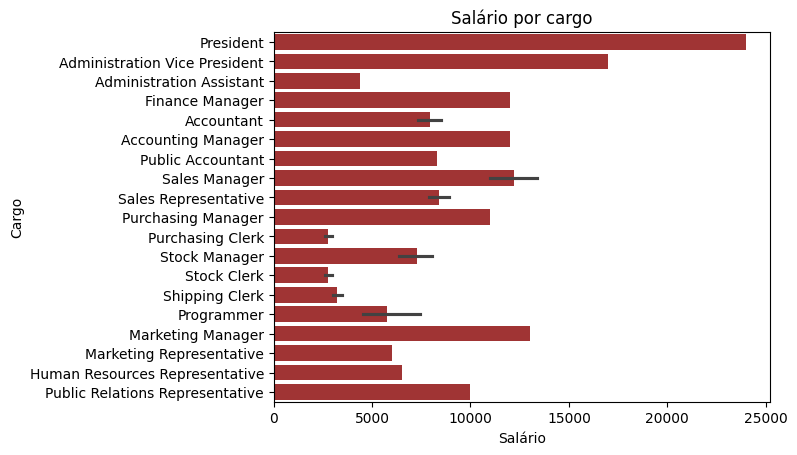

In [84]:
sns.barplot(df1, x="salario", y="cargo",color="firebrick")

plt.title("Salário por cargo")
plt.xlabel("Salário")
plt.ylabel("Cargo")

plt.savefig("salario_cargo.png", bbox_inches='tight')

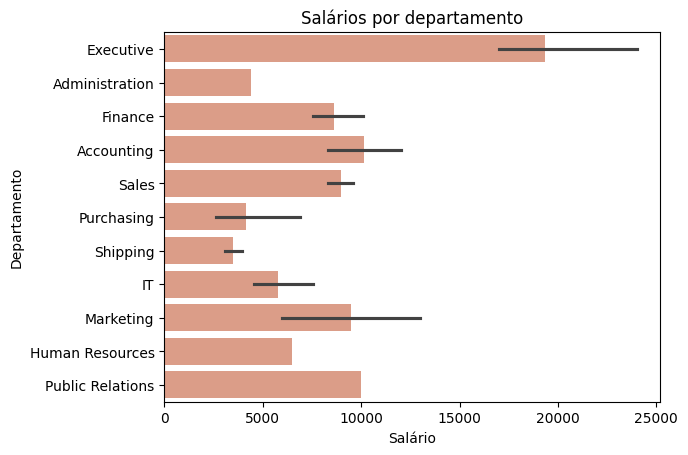

In [85]:
sns.barplot(df1, x="salario", y="nome_do_departamento",color="darksalmon")

plt.title("Salários por departamento")
plt.xlabel("Salário")
plt.ylabel("Departamento")

plt.savefig("salario_departamento.png", bbox_inches='tight')

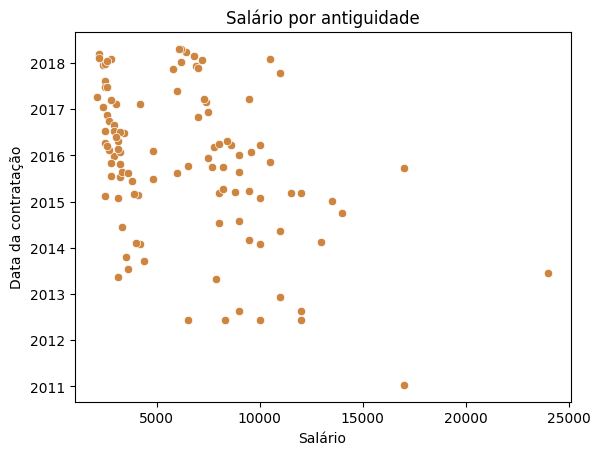

In [88]:
sns.scatterplot(df1,x="salario", y="data_da_contratacao",color="peru")

plt.title("Salário por antiguidade")
plt.xlabel("Salário")
plt.ylabel("Data da contratação")

plt.savefig("salario_antiguidade.png")

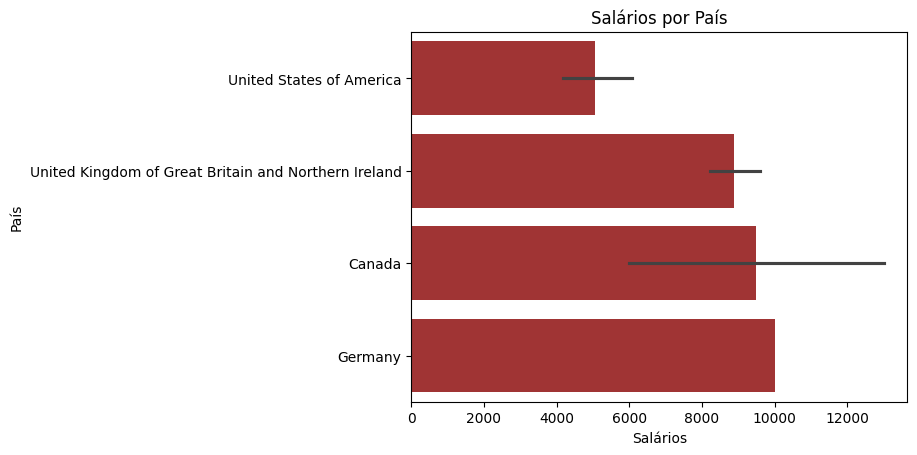

In [87]:
sns.barplot(df2, x="salario", y="nome_do_pais",color="firebrick")

plt.title("Salários por País")
plt.xlabel("Salários")
plt.ylabel("País")

plt.savefig("salario_pais.png", bbox_inches='tight')